In [43]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ITIS_Model_funcs import get_nominal_param,OLS_res,ITIS

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size": 14,
    'figure.constrained_layout.use' : True
})


In [44]:
param_log,IC = get_nominal_param()
IC = [ 2.0,          0.,          0.14759607,  0.,         13.75484703,  3.13344442, 15.73028492,  1.38649737]

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13


if D == '1':
    output_ids = [6,7]
    param_ids = [33, 12, 36, 32, 43, 39, 16, 7, 31, 37, 8, 15, 9, 28, 14]
elif D == '2':
    output_ids = [3,6,7]
    param_ids = [12, 33, 16, 7, 36, 43, 15, 39, 32, 8, 31, 14, 9, 1, 34]
elif D == '3':
    output_ids = [3,4,6,7]
    param_ids =[12, 33, 7, 36, 16, 43, 15, 39, 32, 8, 9, 31, 21, 14, 10, 34]


with open('Multistart_noisydata\\OLSMultistart_noisy' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)
# with open('Multistart_incVar\\OLSMultistart_' + D + dpoints + '.pkl', 'rb') as f:
#     results = pickle.load(f)

t_data = results['t_data']
y_data = results['y_data']
param_opt = results['param_opt']
opt_cost = results['opt_cost']
param_init = results['param_in']
dt = .05
tfinal = np.arange(0,24+dt,dt)
opt_solutions = results['opt_solutions']
#var = results['var']
true_sol = results['true_sol']
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

S = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_log, IC)))

In [45]:

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'\u03B1', 'k', '\u03B2', 'L', '\u03B5', '\u03B4', 'T', 'Nc']

param_titles_latex = [
    r'$d_1$',
    r'$k_1$', r'$k_2$', r'$h_1$', r'$h_2$', r'$h_3$', r'$d_2$',
    r'$k_3$', r'$k_4$', r'$h_4$', r'$d_3$',
    r'$h_5$', r'$h_6$', r'$k_5$', r'$k_6$', r'$h_7$', r'$d_4$',
    r'$b_1$', r'$k_7$', r'$h_8$', r'$k_8$', r'$h_9$', r'$d_5$', r'$h_{10}$',
    r'$b_2$', r'$k_9$', r'$k_{10}$', r'$k_{11}$', r'$d_6$',
    r'$k_{12}$', r'$k_{13}$', r'$k_{14}$', r'$h_{11}$', r'$d_7$',
    r'$k_{15}$', r'$k_{16}$', r'$d_8$',
    r'$\alpha$', r'$k$', r'$\beta$', r'$L$', r'$\epsilon$', r'$\delta$', r'$T$', r'$N_c$'
]


cond = 0
unid = []
p_indices = [param_ids[0]]
for i in range(1,len(param_ids)):
    p_indices.append(param_ids[i])
    S_opt = S[p_indices,:].copy()
    F_opt = S_opt@S_opt.T
    cond = np.linalg.cond(F_opt)
    if cond > 1e+6:
        unid.append(p_indices.pop())
        print("Removed: ", unid[-1])


S_opt = S[p_indices,:].copy()
F_opt = S_opt@S_opt.T
C_opt = np.linalg.inv(F_opt)
selected = [param_titles[i] for i in p_indices]
print("Design : ", D + dpoints)
print("Number of selected parameters:", len(p_indices))
print("Selected Parameters: ",  selected)
print(p_indices)
print("Excluded Parameters: ", [param_titles[i] for i in unid])
print("Condition Number of F:", np.linalg.cond(F_opt))
print("Diagonals of C:", np.diag(C_opt))

Design :  32
Number of selected parameters: 16
Selected Parameters:  ['h6', 'd7', 'k3', 'd8', 'd4', 'T', 'h7', 'β', 'h11', 'k4', 'h4', 'k14', 'h9', 'k6', 'd3', 'k15']
[12, 33, 7, 36, 16, 43, 15, 39, 32, 8, 9, 31, 21, 14, 10, 34]
Excluded Parameters:  []
Condition Number of F: 12074.406089443686
Diagonals of C: [0.18619166 0.21699351 0.17966967 0.46660914 0.49168475 0.52417027
 0.18968438 2.24744903 0.20444063 0.2094942  0.59199087 0.14178105
 0.03264696 1.32606234 0.09359758 0.24482907]


In [46]:
# plt.figure(figsize = (10,3*len(output_ids),))
# for i in range(len(output_ids)):
#     a = .75
#     if i == 1:
#         plt.title('Opt vs true vs obs')
#         plt.legend()
#     plt.subplot(len(output_ids),1,i+1)
#     plt.scatter(t_data,y_data[:,i],marker='x',color='k')
#     for j in range(20):
#         plt.plot(tfinal,opt_solutions[j,:,i].T, color = 'g', alpha = a)
#         #a -= .03
#     plt.plot(tfinal,true_sol[:,output_ids[i]],color='r',label='true model')
# #plt.savefig("FIGS\\Multistart_modelsols_" + N + D + dpoints + ".png")
# plt.show()

In [47]:
# ##  ADD NOISE
# ##Calculating CIS
# ##Calculate standard errors
#
#
# ##initialize container for bounds
# alpha = 0.05
# t_value = stats.t.ppf(1-alpha, len(t_data) * len(output_ids) - len(p_indices))
# #
# # plt.figure(figsize = (5, 4*len(p_indices)))
# # for i in range(len(param_ids)):
# #     CI = np.zeros((20,2))
# #     plt.subplot(len(p_indices), 1, i+1)
# #     for j in range(20):
# #         var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
# #         SE = np.sqrt(var_est * np.diag(C_opt))
# #
# #         CI[j,0] = param_opt[j][i] - t_value * SE[i]
# #         CI[j,1] = param_opt[j][i] + t_value * SE[i]
# #         plt.vlines(x = j, ymin = np.exp(CI[j,0]), ymax = np.exp(CI[j,1]))
# #     #plt.ylim(np.exp(param_log[p_indices[i]] - param_log[p_indices[i]]* .1), np.exp(param_log[p_indices[i]] + param_log[p_indices[i]]* .1))
# #     plt.axhline(np.exp(param_log[p_indices[i]]), linestyle = '--')
# #     plt.scatter(range(20), np.exp(param_opt[:,i]), marker = 'o', color = 'g')
# #     plt.title(param_titles[p_indices[i]])
# # plt.tight_layout()
# # #plt.savefig('FIGS\\post_opt_CIS_nonoise' + D + dpoints + '.png')
# # plt.show()

# fig, axs = plt.subplots(rows,5, figsize = (16,3*rows))
# CI = np.zeros((20,2))
#
#
# for i in range(rows):
#
#     for k in range(5):
#         if i*4 + k>= len(p_indices):
#             for r in range(k,5):
#                 axs[i,r].remove()
#             break
#         for j in range(20):
#             var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
#             SE = np.sqrt(var_est * np.diag(C_opt))
#
#             CI[j,0] = param_opt[j][i*4 + k] - t_value * SE[i*4 + k]
#             CI[j,1] = param_opt[j][i*4 + k] + t_value * SE[i*4 + k]
#
#             axs[i, k].vlines(x = j, ymin = np.exp(CI[j,0]), ymax = np.exp(CI[j,1]))
#         axs[i, k].scatter(range(20), np.exp(param_opt[:,i*4 + k]), marker = 'o', color = 'g')
#         axs[i,k].scatter(range(20), np.exp(param_init[i*4 + k, :]), marker = 'o', color = 'orange')
#         axs[i, k].axhline(np.exp(param_log[p_indices[i*4 + k]]), linestyle = '--')
#         axs[i,k].set_title(param_titles[p_indices[i*4 + k]])
# for ax in axs.flat:
#     ax.set_xticks([])
# fig.tight_layout()
# #plt.savefig("FIGS\\CI_matrix_" + N + D + dpoints + ".png")
#
#         #print(CI[i,0], param_opt[0][i], CI [i,1])
#         #print(np.exp(CI[i,0]), np.exp(param_log[p_indices[i]]), np.exp(CI [i,1]))
#      #print(np.exp(CI[i,0])/np.exp(param_log[p_indices[i]])-1, 0, np.exp(CI [i,1])/np.exp(param_log[p_indices[i]])-1)
# ##
#
# ##HOW DOES LOG SCALE AFFECT OUTCOME?

In [48]:
# ##  ADD NOISE
# ##Calculating CIS
# from scipy import stats
# ##Calculate standard errors
# 
# 
# ##initialize container for bounds

# #
# # plt.figure(figsize = (5, 4*len(p_indices)))
# # for i in range(len(param_ids)):
# #     CI = np.zeros((20,2))
# #     plt.subplot(len(p_indices), 1, i+1)
# #     for j in range(20):
# #         var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
# #         SE = np.sqrt(var_est * np.diag(C_opt))
# #
# #         CI[j,0] = param_opt[j][i] - t_value * SE[i]
# #         CI[j,1] = param_opt[j][i] + t_value * SE[i]
# #         plt.vlines(x = j, ymin = np.exp(CI[j,0]), ymax = np.exp(CI[j,1]))
# #     #plt.ylim(np.exp(param_log[p_indices[i]] - param_log[p_indices[i]]* .1), np.exp(param_log[p_indices[i]] + param_log[p_indices[i]]* .1))
# #     plt.axhline(np.exp(param_log[p_indices[i]]), linestyle = '--')
# #     plt.scatter(range(20), np.exp(param_opt[:,i]), marker = 'o', color = 'g')
# #     plt.title(param_titles[p_indices[i]])
# # plt.tight_layout()
# # #plt.savefig('FIGS\\post_opt_CIS_nonoise' + D + dpoints + '.png')
# # plt.show()
# if len(p_indices) <= 15:
#     rows = 3
# else:
#     rows = 4
# 
# # fig, axs = plt.subplots(rows,5, figsize = (16,3*rows))
# CI = np.zeros((len(p_indices),20,2))
# CI_rel = np.zeros((20,2))
# ylims = []
# CV_rel = np.zeros(len(p_indices))
# 

# 
# for i in range(rows):
# 
#     for k in range(5):
#         if i*4 + k>= len(p_indices):
#             for r in range(k,5):
#                 axs[i,r].remove()
#             break
#         for j in range(20):
#             var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
# 
#             CV_rel[i*4 + k] = np.sqrt(var_est) / np.mean(param_opt[:,i*4+k])
#             SE = np.sqrt(var_est * np.diag(C_opt))
# 
#             CI[i*4 + k,j,0] = param_opt[j][i*4 + k] - t_value * SE[i*4 + k]
#             CI[i*4 + k,j,1] = param_opt[j][i*4 + k] + t_value * SE[i*4 + k]
# 
#             CI_rel[j,0] = (CI[i*4 + k,j,0].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]
#             CI_rel[j,1] = (CI[i*4 + k,j,1].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]
# 
#         #     axs[i, k].vlines(x = j, ymin = CI_rel[j,0], ymax = CI_rel[j,1])
#         # # axs[i, k].scatter(range(20), np.exp(param_opt[:,i*4 + k]), marker = 'o', color = 'g')
#         # # axs[i, k].axhline(np.exp(param_log[p_indices[i*4 + k]]), linestyle = '--')
#         # axs[i, k].scatter(range(20), (param_opt[:,i*4 + k]- param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]], marker = 'o', color = 'g')
#         # axs[i, k].axhline(0, linestyle = '--')
#         #
#         # axs[i,k].set_title(param_titles[p_indices[i*4 + k]])
# 
# 
#         #symmetrize_y_axis(axs[i,k]) #MAKES Y AXIS SYMMETRIC ABOUT 0. CAN BE COMMENTED OUT
#         ylims.append(axs[i,k].get_ylim())
# 
# # for ax in axs.flat:
# #     ax.set_xticks([])
# # fig.tight_layout()
# #
# # #plt.savefig("FIGS\\CI_Sym_noisy" + D + dpoints + ".png")
# # plt.show()
#         #print(CI[i,0], param_opt[0][i], CI [i,1])
#         #print(np.exp(CI[i,0]), np.exp(param_log[p_indices[i]]), np.exp(CI [i,1]))
#      #print(np.exp(CI[i,0])/np.exp(param_log[p_indices[i]])-1, 0, np.exp(CI [i,1])/np.exp(param_log[p_indices[i]])-1)

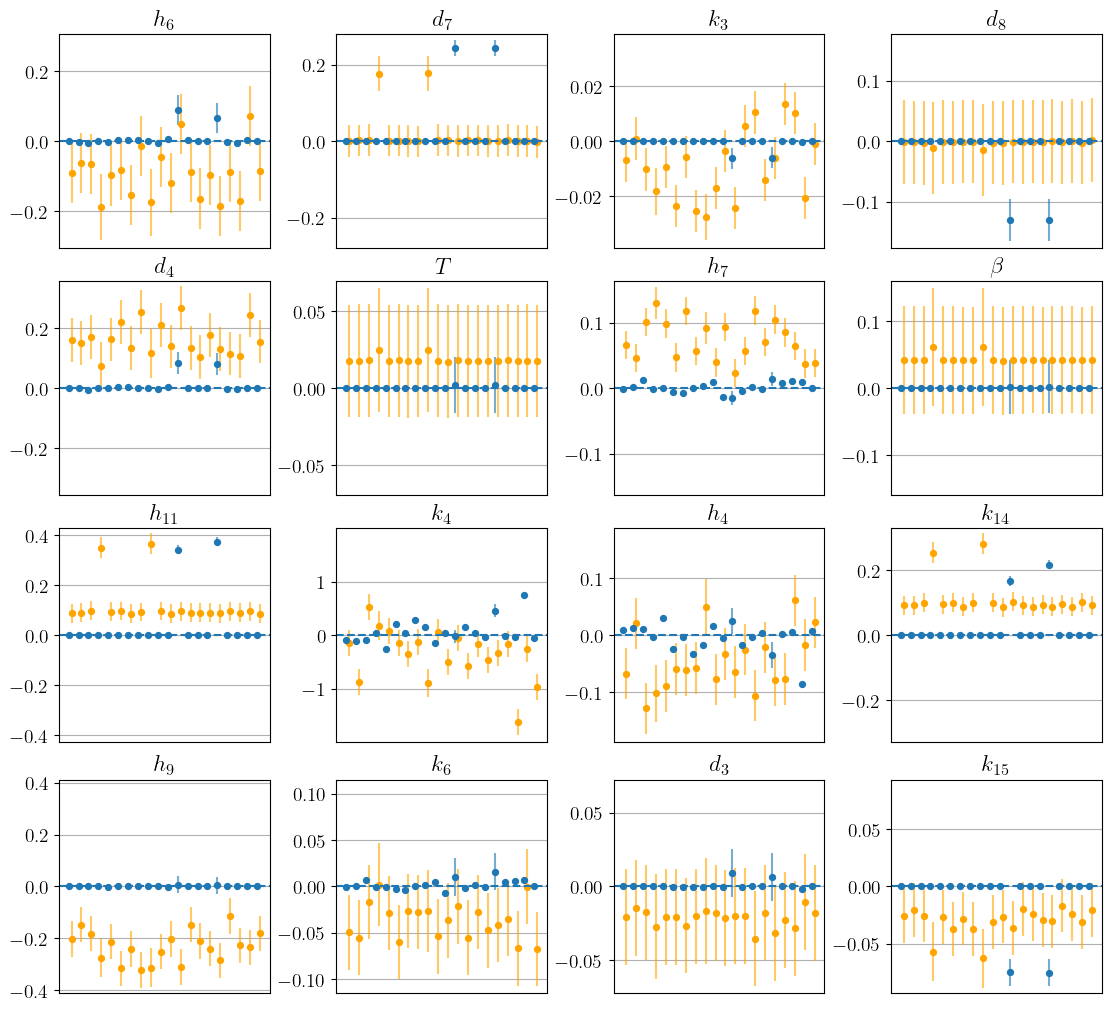

In [49]:
with open('Multistart_results\\OLSMultistart_nonoise_' + D + dpoints + '.pkl', 'rb') as f:
    results2 = pickle.load(f)
# with open('Multistart_incVar\\OLSMultistart_' + D + dpoints + '.pkl', 'rb') as f:
#     results = pickle.load(f)

from scipy import stats
alpha = 0.05
t_value = stats.t.ppf(1-alpha, len(t_data) * len(output_ids) - len(p_indices))


t_data2 = results2['t_data']
y_data2 = results2['y_data']
param_opt2 = results2['param_opt']
opt_cost2 = results2['opt_cost']
param_init2 = results2['param_in']


def symmetrize_y_axis(axes):
    y_max = np.max(np.abs(axes.get_ylim()))
    axes.set_ylim(ymin=-y_max, ymax=y_max)

dt = .05
tfinal = np.arange(0,24+dt,dt)
opt_solutions2 = results2['opt_solutions']
#var = results['var']
true_sol = results['true_sol']

fig, axs = plt.subplots(4,4, figsize = (11,10))

CI = np.zeros((len(p_indices),20,2))
CI_rel = np.zeros((20,2))
CI2 = np.zeros((len(p_indices),20,2))
CI_rel2 = np.zeros((20,2))

##Recalculate sensitivity for noiseless
S2 = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S2[i, :] = ((1 / h) * (OLS_res(param_delta, y_data2, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data2, t_data, i, output_ids, param_log, IC)))

S_opt2 = S2[p_indices,:].copy()
F_opt2 = S_opt2@S_opt2.T
C_opt2 = np.linalg.inv(F_opt2)

for i in range(4):

    for k in range(4):
        if i*4 + k >= len(p_indices):
            axs[i,k].remove()
            break
        axs[i,k].grid(zorder = .5)
        for j in range(20):
            var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
            var_est2 = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost2[j]

            SE = np.sqrt(var_est * np.diag(C_opt))
            SE2 = np.sqrt(var_est2 * np.diag(C_opt2))

            CI[i*4 + k,j,0] = param_opt[j][i*4 + k] - t_value * SE[i*4 + k]
            CI[i*4 + k,j,1] = param_opt[j][i*4 + k] + t_value * SE[i*4 + k]

            CI2[i*4 + k,j,0] = param_opt2[j][i*4 + k] - t_value * SE2[i*4 + k]
            CI2[i*4 + k,j,1] = param_opt2[j][i*4 + k] + t_value * SE2[i*4 + k]

            CI_rel[j,0] = (CI[i*4 + k,j,0].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]
            CI_rel[j,1] = (CI[i*4 + k,j,1].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]

            CI_rel2[j,0] = (CI2[i*4 + k,j,0].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]
            CI_rel2[j,1] = (CI2[i*4 + k,j,1].copy() - param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]]

            axs[i, k].vlines(x = j+.3, ymin = CI_rel[j,0], ymax = CI_rel[j,1], color = 'orange', alpha = .6)
            axs[i, k].vlines(x = j, ymin = CI_rel2[j,0], ymax = CI_rel2[j,1], alpha = .6)

        # axs[i, k].scatter(range(20), np.exp(param_opt[:,i*4 + k]), marker = 'o', color = 'g')
        # axs[i, k].axhline(np.exp(param_log[p_indices[i*4 + k]]), linestyle = '--')
        axs[i, k].scatter(np.arange(.3,20.3,1), (param_opt[:,i*4 + k]- param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]], marker = 'o', color = 'orange', label = 'noisy', s = 18, zorder = 2)
        axs[i, k].scatter(range(20), (param_opt2[:,i*4 + k]- param_log[p_indices[i*4 + k]])/param_log[p_indices[i*4 + k]], marker = 'o', label = 'noiseless', s = 18, zorder = 2)
        axs[i, k].axhline(0, linestyle = '--')

        axs[i,k].set_title(param_titles_latex[p_indices[i*4 + k]])

        symmetrize_y_axis(axs[i,k])
for ax in axs.flat:
    ax.set_xticks([])

#fig.tight_layout()

plt.savefig('epsFigs\\multiStartGraphs\\CI_Combined' + D + dpoints + '.pdf')
plt.show()